# Demand Forecasting — Daily Booking Volume

**Goal:** forecast future daily booking volume from the `fact_bookings` / `dim_date` star schema built earlier in this project.

**What this notebook does, in order:**
1. Connect to Postgres and pull daily booking counts
2. Explore the time series (trend, weekly seasonality, weekday vs weekend)
3. Decompose the series into trend / seasonal / residual components
4. Split into train/test and fit a few forecasting models
5. Compare model accuracy (MAE / RMSE / MAPE)
6. Refit the best model on the full history and forecast the next 30 days
7. Export the forecast (CSV + optional Postgres table)

**Note:** this notebook expects the same `.env` file used by `scripts/incremental.py` (Postgres connection details), and assumes `fact_bookings` + `dim_date` are already populated (see `model/09_pop_dims.sql` and `model/10_pop_fact.sql`).

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
from dotenv import load_dotenv

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 1. Connect to Postgres

Uses the same environment variables as `scripts/incremental.py`.

In [3]:
load_dotenv()

PG_HOST = os.getenv("POSTGRES_HOST", "localhost")
PG_PORT = os.getenv("POSTGRES_PORT", "5432")
PG_DB   = os.getenv("POSTGRES_DATABASE", "postgres")
PG_USER = os.getenv("POSTGRES_USERNAME", "postgres")
PG_PASS = os.getenv("POSTGRES_PASSWORD", "")

engine = create_engine(f"postgresql+psycopg2://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}")

with engine.connect() as conn:
    print("Connected:", conn.engine.url.database)

Connected: Uber


## 2. Load daily booking volume

Pulls one row per calendar day: total bookings, plus weekday/weekend flag from `dim_date` so we can inspect weekly seasonality later.

In [4]:
query = """
SELECT
    d.full_date,
    d.day_of_week,
    d.is_weekend,
    COUNT(*) AS total_bookings
FROM fact_bookings f
JOIN dim_date d ON d.date_key = f.date_key
GROUP BY d.full_date, d.day_of_week, d.is_weekend
ORDER BY d.full_date;
"""

df = pd.read_sql(query, engine)
df["full_date"] = pd.to_datetime(df["full_date"])
df = df.set_index("full_date").sort_index()

print(f"Date range: {df.index.min().date()} -> {df.index.max().date()}  ({len(df)} days)")
df.head()

Date range: 2024-07-01 -> 2024-07-31  (31 days)


,day_of_week,is_weekend,total_bookings
full_date,,,
2024-07-01,Monday,False,3351
2024-07-02,Tuesday,False,3388
2024-07-03,Wednesday,False,3358
2024-07-04,Thursday,False,3274
2024-07-05,Friday,False,3306


## 3. Exploratory data analysis

Before fitting any model, look at the raw shape of the series: is there a trend? A weekly pattern? Any gaps or obvious outlier days?

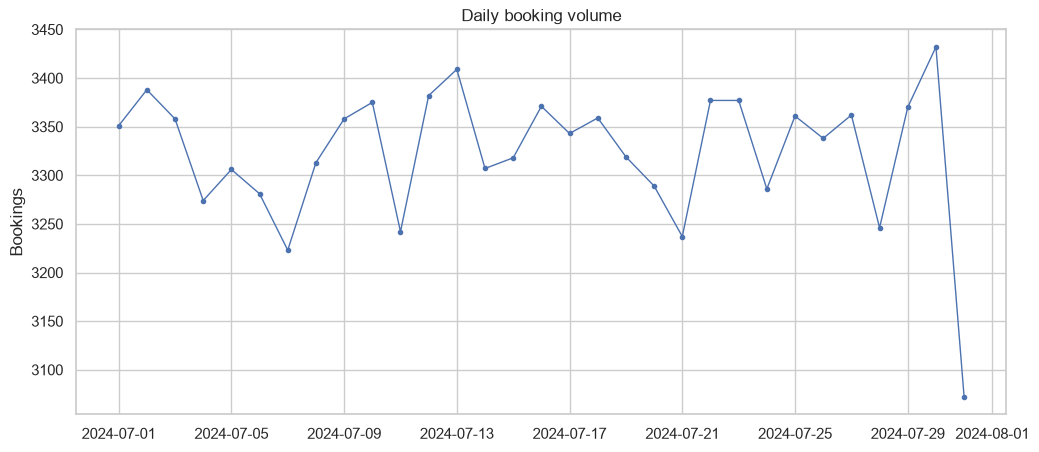

In [5]:
fig, ax = plt.subplots()
ax.plot(df.index, df["total_bookings"], marker="o", markersize=3, linewidth=1)
ax.set_title("Daily booking volume")
ax.set_ylabel("Bookings")
plt.show()

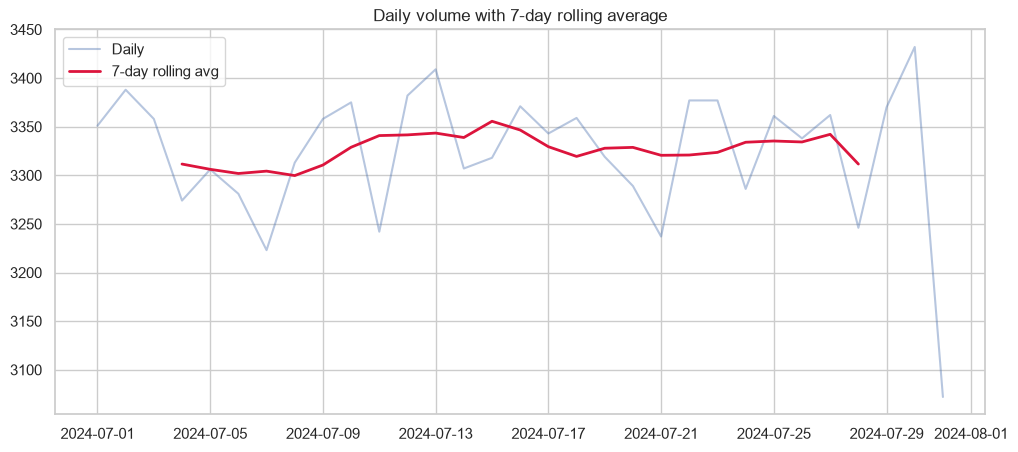

In [6]:
# 7-day rolling average smooths out day-to-day noise so the trend is easier to see
df["rolling_7d"] = df["total_bookings"].rolling(7, center=True).mean()

fig, ax = plt.subplots()
ax.plot(df.index, df["total_bookings"], alpha=0.4, label="Daily")
ax.plot(df.index, df["rolling_7d"], color="crimson", linewidth=2, label="7-day rolling avg")
ax.legend()
ax.set_title("Daily volume with 7-day rolling average")
plt.show()

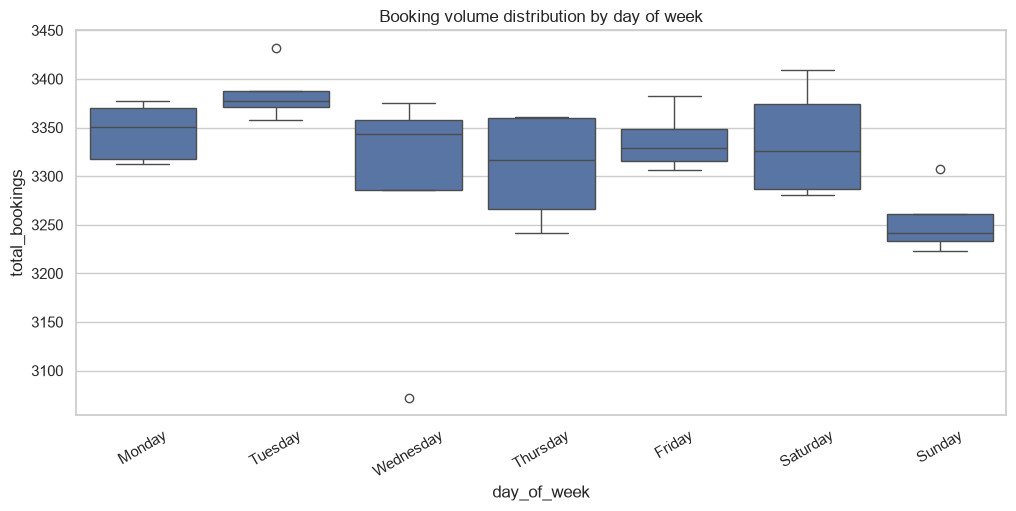

In [7]:
# Weekly seasonality check: does booking volume vary by day of week?
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df_plot = df.copy()
df_plot["day_of_week"] = df_plot["day_of_week"].str.strip()

fig, ax = plt.subplots()
sns.boxplot(data=df_plot, x="day_of_week", y="total_bookings", order=order, ax=ax)
ax.set_title("Booking volume distribution by day of week")
plt.xticks(rotation=30)
plt.show()

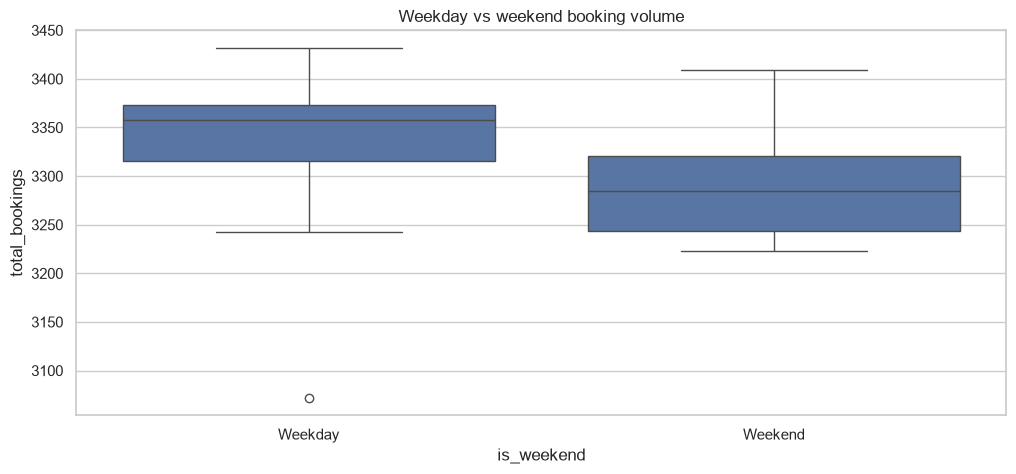

In [8]:
# Weekday vs weekend, side by side
fig, ax = plt.subplots()
sns.boxplot(data=df_plot, x="is_weekend", y="total_bookings", ax=ax)
ax.set_xticklabels(["Weekday", "Weekend"])
ax.set_title("Weekday vs weekend booking volume")
plt.show()

## 4. Seasonal decomposition

Splits the series into trend, weekly seasonal pattern, and leftover residual noise. `period=7` assumes a **weekly** seasonal cycle — the most likely pattern for ride bookings.

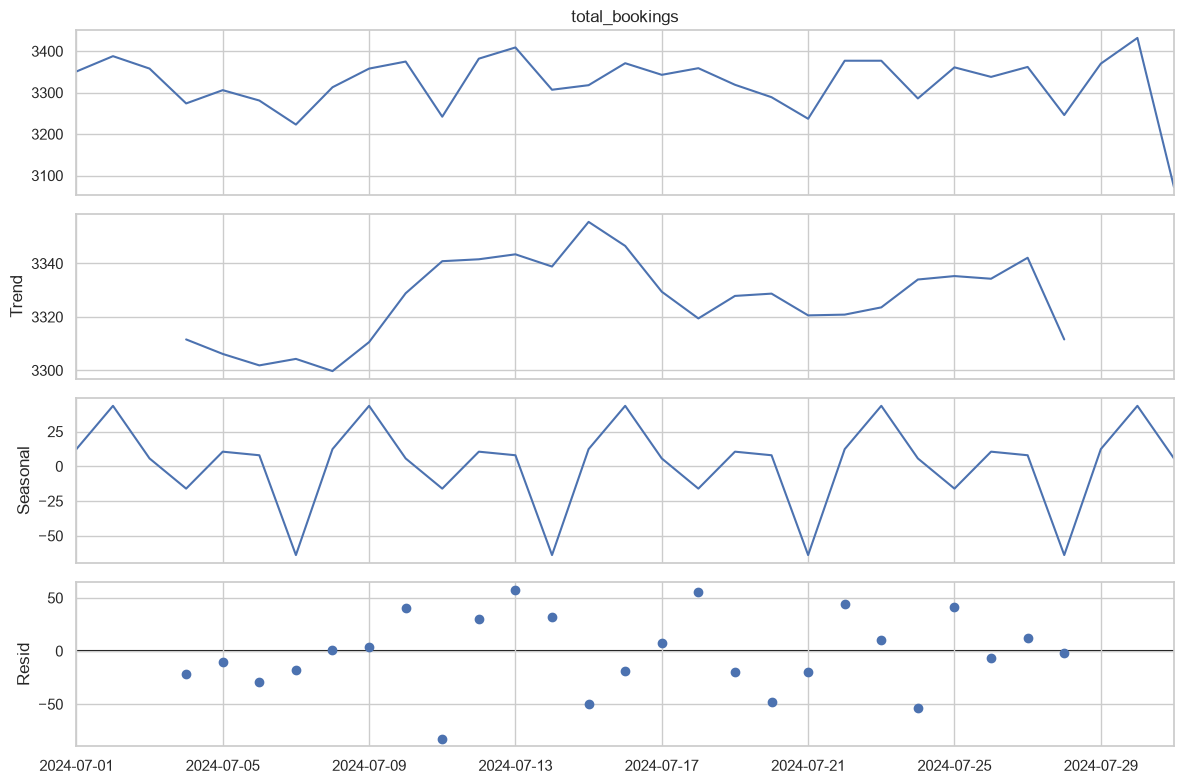

In [9]:
series = df["total_bookings"].asfreq("D").interpolate()  # fill any missing calendar days

decomposition = seasonal_decompose(series, model="additive", period=7)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

## 5. Train / test split

Hold out the **last 14 days** as a test set. Models are fit only on data before the holdout, then scored on how well they predict it.

In [10]:
HORIZON = 14  # days held out for testing

train = series.iloc[:-HORIZON]
test = series.iloc[-HORIZON:]

print(f"Train: {train.index.min().date()} -> {train.index.max().date()}  ({len(train)} days)")
print(f"Test:  {test.index.min().date()} -> {test.index.max().date()}  ({len(test)} days)")

Train: 2024-07-01 -> 2024-07-17  (17 days)
Test:  2024-07-18 -> 2024-07-31  (14 days)


In [11]:
def evaluate(actual, predicted, name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual.replace(0, np.nan))) * 100
    return {"model": name, "MAE": round(mae, 2), "RMSE": round(rmse, 2), "MAPE_%": round(mape, 2)}

results = []

## 6. Baseline models

Simple benchmarks any real model needs to beat:
- **Naive**: tomorrow = today
- **Seasonal naive**: tomorrow = same day last week (captures weekly seasonality with zero fitting)

In [12]:
naive_pred = pd.Series(train.iloc[-1], index=test.index)
results.append(evaluate(test, naive_pred, "Naive (last value)"))

seasonal_naive_pred = pd.Series(train.iloc[-7:].values.tolist() * (HORIZON // 7 + 1), index=train.index[-7:].tolist() + list(test.index))
seasonal_naive_pred = pd.Series(
    [train.iloc[-7 + (i % 7)] for i in range(HORIZON)],
    index=test.index
)
results.append(evaluate(test, seasonal_naive_pred, "Seasonal naive (same day last week)"))

pd.DataFrame(results)

,model,MAE,RMSE,MAPE_%
0,Naive (last value),60.79,89.74,1.88
1,Seasonal naive (same day last week),81.93,101.99,2.51


## 7. Holt-Winters Exponential Smoothing

Models trend + weekly seasonality explicitly. Usually a strong, low-effort choice for series like this.

In [13]:
hw_model = ExponentialSmoothing(
    train, trend="add", seasonal="add", seasonal_periods=7
).fit()

hw_pred = hw_model.forecast(HORIZON)
results.append(evaluate(test, hw_pred, "Holt-Winters (additive, weekly)"))

pd.DataFrame(results)

,model,MAE,RMSE,MAPE_%
0,Naive (last value),60.79,89.74,1.88
1,Seasonal naive (same day last week),81.93,101.99,2.51
2,"Holt-Winters (additive, weekly)",73.30,95.78,2.23


## 8. SARIMA

A more flexible model that can capture autocorrelation the exponential smoothing model might miss. `order` and `seasonal_order` here are reasonable starting points, not exhaustively tuned — see the "Next steps" section at the end for how to improve this.

In [14]:
sarima_model = SARIMAX(
    train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)

sarima_pred = sarima_model.forecast(HORIZON)
results.append(evaluate(test, sarima_pred, "SARIMA(1,1,1)(1,1,1,7)"))

pd.DataFrame(results)

,model,MAE,RMSE,MAPE_%
0,Naive (last value),60.79,89.74,1.88
1,Seasonal naive (same day last week),81.93,101.99,2.51
2,"Holt-Winters (additive, weekly)",73.30,95.78,2.23
3,"SARIMA(1,1,1)(1,1,1,7)",79.76,102.53,2.42


## 9. Model comparison

,MAE,RMSE,MAPE_%
model,,,
Naive (last value),60.79,89.74,1.88
"Holt-Winters (additive, weekly)",73.30,95.78,2.23
"SARIMA(1,1,1)(1,1,1,7)",79.76,102.53,2.42
Seasonal naive (same day last week),81.93,101.99,2.51


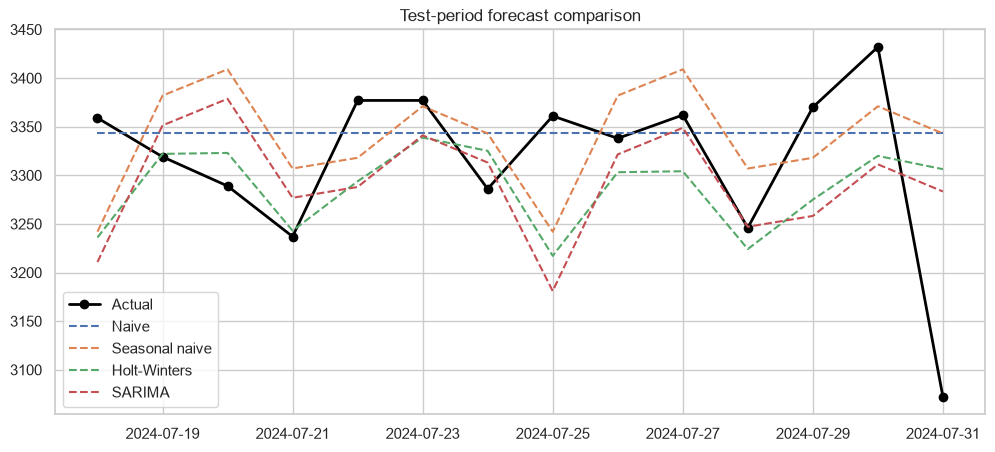

Best model on this holdout: Naive (last value)


In [15]:
comparison = pd.DataFrame(results).set_index("model").sort_values("MAE")
display(comparison)

fig, ax = plt.subplots()
ax.plot(test.index, test.values, label="Actual", color="black", linewidth=2, marker="o")
ax.plot(test.index, naive_pred, "--", label="Naive")
ax.plot(test.index, seasonal_naive_pred, "--", label="Seasonal naive")
ax.plot(test.index, hw_pred, "--", label="Holt-Winters")
ax.plot(test.index, sarima_pred, "--", label="SARIMA")
ax.legend()
ax.set_title("Test-period forecast comparison")
plt.show()

best_model_name = comparison.index[0]
print(f"Best model on this holdout: {best_model_name}")

## 10. Forecast future demand

Refit the best-performing model on the **full** history (train + test) and project forward 30 days. Swap `FUTURE_MODEL` below if a different model wins on your actual data.

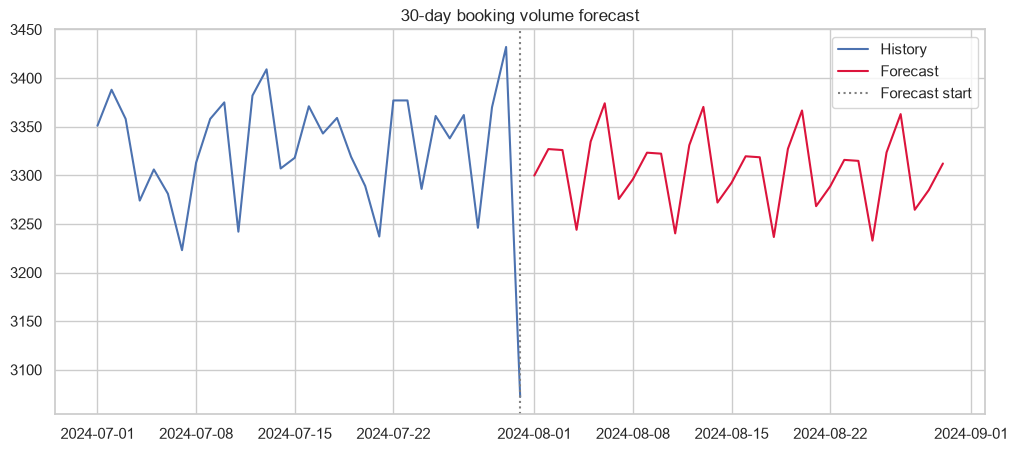

,forecast
2024-08-01,3299.728404
2024-08-02,3326.977579
2024-08-03,3325.975747
2024-08-04,3243.976354
2024-08-05,3334.671197
2024-08-06,3374.065161
2024-08-07,3275.672952
2024-08-08,3296.018745
2024-08-09,3323.267920
2024-08-10,3322.266088


In [16]:
FUTURE_DAYS = 30

# Refit Holt-Winters on the full series (change this block if SARIMA/another model won above)
final_model = ExponentialSmoothing(
    series, trend="add", seasonal="add", seasonal_periods=7
).fit()

forecast = final_model.forecast(FUTURE_DAYS)
forecast.name = "forecast"

fig, ax = plt.subplots()
ax.plot(series.index, series.values, label="History")
ax.plot(forecast.index, forecast.values, label="Forecast", color="crimson")
ax.axvline(series.index.max(), color="gray", linestyle=":", label="Forecast start")
ax.legend()
ax.set_title(f"{FUTURE_DAYS}-day booking volume forecast")
plt.show()

forecast.to_frame()

## 11. Export the forecast

Saves the forecast as a CSV, and optionally writes it to a new Postgres table (`demand_forecast`) so it can be picked up by a BI tool alongside `fact_bookings`.

In [17]:
output_df = forecast.reset_index()
output_df.columns = ["forecast_date", "predicted_bookings"]
output_df["generated_at"] = pd.Timestamp.now()

output_path = "demand_forecast.csv"
output_df.to_csv(output_path, index=False)
print(f"Saved forecast to {output_path}")

output_df.head()

Saved forecast to demand_forecast.csv


,forecast_date,predicted_bookings,generated_at
0,2024-08-01,3299.728404,2026-07-28 16:06:06.751202
1,2024-08-02,3326.977579,2026-07-28 16:06:06.751202
2,2024-08-03,3325.975747,2026-07-28 16:06:06.751202
3,2024-08-04,3243.976354,2026-07-28 16:06:06.751202
4,2024-08-05,3334.671197,2026-07-28 16:06:06.751202


In [18]:
# Optional: write the forecast to Postgres for downstream use
WRITE_TO_DB = False  # flip to True to actually write

if WRITE_TO_DB:
    output_df.to_sql("demand_forecast", engine, if_exists="replace", index=False)
    print("Forecast written to table: demand_forecast")

## Notes / next steps

- **Holidays and promotions aren't modeled.** Spikes or dips tied to specific dates (festivals, promo days, outages) will look like noise to these models. Adding a holiday/event calendar as an exogenous regressor (`SARIMAX(..., exog=...)`) would help.
- **SARIMA order wasn't tuned.** `pmdarima.auto_arima` (or a manual grid search over `order`/`seasonal_order`) would likely improve on `(1,1,1)(1,1,1,7)`.
- **Only one seasonal period (weekly) is modeled.** If enough history accumulates, a yearly/monthly seasonal component might also be worth testing.
- **Confidence intervals aren't shown for the final forecast.** Both `ExponentialSmoothing` and `SARIMAX` can produce prediction intervals (`get_prediction()` for SARIMAX) — worth adding once you've picked a final model, so the forecast communicates uncertainty, not just a point estimate.
